In [1]:
import pandas as pd

# ==============================
# 1. LOAD DATA (skip metadata rows)
# ==============================
urban = pd.read_csv("urban.csv", skiprows=4)
pm25 = pd.read_csv("pm25.csv", skiprows=4)

# ==============================
# 2. CLEAN DATA (remove empty columns)
# ==============================
urban = urban.loc[:, ~urban.columns.str.contains('^Unnamed')]
pm25 = pm25.loc[:, ~pm25.columns.str.contains('^Unnamed')]

# ==============================
# 3. CONVERT TO LONG FORMAT
# ==============================
urban_long = urban.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="Urban_Population"
)

pm25_long = pm25.melt(
    id_vars=["Country Name", "Country Code"],
    var_name="Year",
    value_name="PM25"
)

# ==============================
# 4. FIX DATA TYPES
# ==============================
urban_long["Year"] = pd.to_numeric(urban_long["Year"], errors="coerce")
pm25_long["Year"] = pd.to_numeric(pm25_long["Year"], errors="coerce")

urban_long = urban_long.dropna(subset=["Year"])
pm25_long = pm25_long.dropna(subset=["Year"])

urban_long["Year"] = urban_long["Year"].astype(int)
pm25_long["Year"] = pm25_long["Year"].astype(int)

# ==============================
# 5. MERGE DATASETS
# ==============================
merged = pd.merge(
    urban_long,
    pm25_long,
    on=["Country Name", "Country Code", "Year"]
)

# ==============================
# 6. CLEAN FINAL DATA
# ==============================
merged = merged.dropna(subset=["Urban_Population", "PM25"])

# ==============================
# 7. PREVIEW
# ==============================
print(merged.head())
print("\nShape:", merged.shape)

                     Country Name Country Code  Year Urban_Population  \
7981  Africa Eastern and Southern          AFE  1990       78878788.0   
7982                  Afghanistan          AFG  1990        2079567.0   
7983   Africa Western and Central          AFW  1990       69351822.0   
7984                       Angola          AGO  1990        4403833.0   
7985                      Albania          ALB  1990        1179772.0   

           PM25  
7981  25.111399  
7982  64.174097  
7983  60.240684  
7984  23.831767  
7985  22.961579  

Shape: (7688, 5)


Matplotlib is building the font cache; this may take a moment.


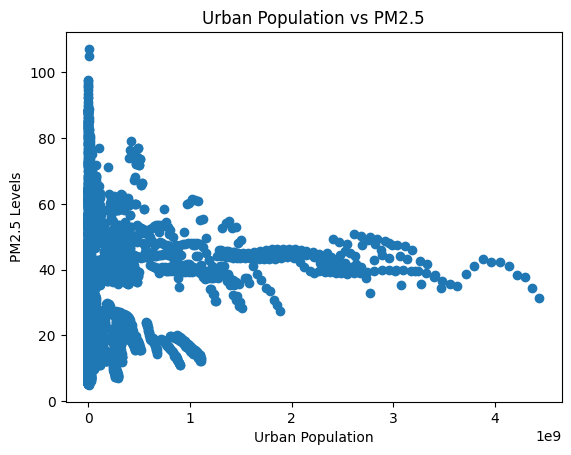

In [2]:
import matplotlib.pyplot as plt

plt.scatter(merged["Urban_Population"], merged["PM25"])
plt.xlabel("Urban Population")
plt.ylabel("PM2.5 Levels")
plt.title("Urban Population vs PM2.5")
plt.show()

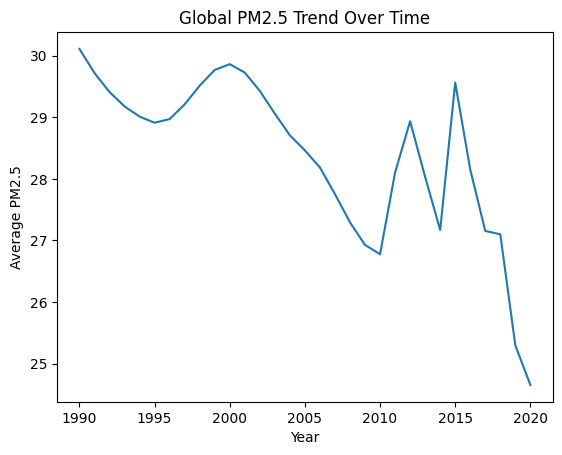

In [3]:
# Average PM2.5 per year
yearly_pm25 = merged.groupby("Year")["PM25"].mean()

# Plot
plt.plot(yearly_pm25.index, yearly_pm25.values)
plt.xlabel("Year")
plt.ylabel("Average PM2.5")
plt.title("Global PM2.5 Trend Over Time")
plt.show()

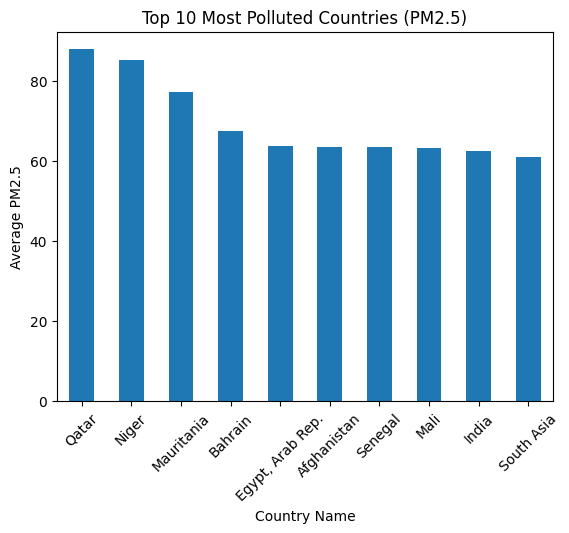

In [4]:
# Top 10 countries by average PM2.5
top_countries = merged.groupby("Country Name")["PM25"].mean().sort_values(ascending=False).head(10)

# Plot
top_countries.plot(kind="bar")
plt.ylabel("Average PM2.5")
plt.title("Top 10 Most Polluted Countries (PM2.5)")
plt.xticks(rotation=45)
plt.show()

In [5]:
merged.to_csv("final_dataset.csv", index=False)